In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/DS102-ML/project/notebook')

print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/DS102-ML/project/notebook


## Preprocessing & Features Engineering

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.auto import tqdm
import joblib
import time
import os
from datetime import datetime

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    confusion_matrix,
    average_precision_score
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


class ProcessFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, drop_duplicates=True, verbose=True):
        self.drop_duplicates = drop_duplicates
        self.verbose = verbose

    def fit(self, X, y=None):
        df = X.copy()

        df["is_root"] = (df["userId"] == 0).astype(int)
        df["is_child_process"] = (df["parentProcessId"] != 1).astype(int)
        df["return_is_error"] = (df["returnValue"] < 0).astype(int)

        self.mnt_freq_ = df.groupby("mountNamespace").size()
        self.mnt_unique_process_ = df.groupby("mountNamespace")["processId"].nunique()

        self.user_freq_ = df.groupby("userId").size()
        self.user_unique_process_ = df.groupby("userId")["processId"].nunique()
        self.user_root_ratio_ = df.groupby("userId")["is_root"].mean()
        self.user_error_ratio_ = df.groupby("userId")["return_is_error"].mean()

        self.proc_freq_ = df.groupby("processId").size()
        self.proc_unique_parent_ = df.groupby("processId")["parentProcessId"].nunique()
        self.proc_root_ratio_ = df.groupby("processId")["is_root"].mean()
        self.proc_child_ratio_ = df.groupby("processId")["is_child_process"].mean()
        self.proc_error_ratio_ = df.groupby("processId")["return_is_error"].mean()
        self.proc_avg_args_ = df.groupby("processId")["argsNum"].mean()

        self.parent_freq_ = df.groupby("parentProcessId").size()
        self.parent_unique_child_ = df.groupby("parentProcessId")["processId"].nunique()
        self.parent_root_child_ratio_ = df.groupby("parentProcessId")["is_root"].mean()
        self.parent_error_ratio_ = df.groupby("parentProcessId")["return_is_error"].mean()

        self.global_freq_ = 1
        self.global_ratio_ = df["return_is_error"].mean()
        self.global_args_ = df["argsNum"].mean()

        if self.verbose:
            print("✅ Hoàn tất fit đặc trưng trên tập huấn luyện")

        return self

    def transform(self, X):
        df = X.copy()

        if self.verbose:
            print(f"🔄 Bắt đầu transform {len(df):,} dòng dữ liệu")

        if self.drop_duplicates:
            df = df.drop_duplicates().reset_index(drop=True)

        if "threadId" in df.columns:
            df["same_process_threadId"] = (df["processId"] == df["threadId"]).astype(int)
            df.drop(columns="threadId", inplace=True, errors="ignore")

        df["is_root"] = (df["userId"] == 0).astype(int)
        df["is_child_process"] = (df["parentProcessId"] != 1).astype(int)

        df["return_is_error"] = (df["returnValue"] < 0).astype(int)
        df["return_is_zero"] = (df["returnValue"] == 0).astype(int)
        df["return_is_positive"] = (df["returnValue"] > 0).astype(int)

        df["mnt_freq"] = df["mountNamespace"].map(self.mnt_freq_).fillna(self.global_freq_)
        df["mnt_unique_process"] = df["mountNamespace"].map(self.mnt_unique_process_).fillna(self.global_freq_)

        df["user_freq"] = df["userId"].map(self.user_freq_).fillna(self.global_freq_)
        df["user_unique_process"] = df["userId"].map(self.user_unique_process_).fillna(self.global_freq_)
        df["user_root_ratio"] = df["userId"].map(self.user_root_ratio_).fillna(self.global_ratio_)
        df["user_error_ratio"] = df["userId"].map(self.user_error_ratio_).fillna(self.global_ratio_)

        df["proc_freq"] = df["processId"].map(self.proc_freq_).fillna(self.global_freq_)
        df["proc_unique_parent"] = df["processId"].map(self.proc_unique_parent_).fillna(self.global_freq_)
        df["proc_root_ratio"] = df["processId"].map(self.proc_root_ratio_).fillna(self.global_ratio_)
        df["proc_child_ratio"] = df["processId"].map(self.proc_child_ratio_).fillna(self.global_ratio_)
        df["proc_error_ratio"] = df["processId"].map(self.proc_error_ratio_).fillna(self.global_ratio_)
        df["proc_avg_args"] = df["processId"].map(self.proc_avg_args_).fillna(self.global_args_)

        df["parent_freq"] = df["parentProcessId"].map(self.parent_freq_).fillna(self.global_freq_)
        df["parent_unique_child"] = df["parentProcessId"].map(self.parent_unique_child_).fillna(self.global_freq_)
        df["parent_root_child_ratio"] = df["parentProcessId"].map(
            self.parent_root_child_ratio_
        ).fillna(self.global_ratio_)
        df["parent_error_ratio"] = df["parentProcessId"].map(
            self.parent_error_ratio_
        ).fillna(self.global_ratio_)

        if self.verbose:
            print(f"✅ Hoàn tất transform, kích thước cuối: {df.shape}")

        return df


DATA_PATH = '../data/train.csv'
PREPROCESSING_SAVE_PATH = '../models/preprocessing'

print("="*70)
print("🚀 LOAD VÀ CHUẨN BỊ DỮ LIỆU")
print("="*70)

print(f"\n📂 Đang load dữ liệu từ: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
print(f"✅ Load thành công! Shape: {df.shape}")
print(f"   ↳ Columns: {list(df.columns)}")

print(f"\n🔧 Áp dụng Feature Engineering...")
feature_engineer = ProcessFeatureEngineer(verbose=True, drop_duplicates=False)
df_processed = feature_engineer.fit_transform(df)
print(f"✅ Feature Engineering hoàn tất! New shape: {df_processed.shape}")

X = df_processed.drop(columns=['target'])
y = df_processed['target']
groups = df_processed['processId']

print(f"\n📊 Phân bố class:")
print(y.value_counts().to_string())
print(f"   ↳ Class imbalance ratio: {y.value_counts().max() / y.value_counts().min():.2f}")

print(f"\n✂️  GroupShuffleSplit (80-20) theo processId...")
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]
X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

print(f"✅ Split hoàn tất!")
print(f"   ↳ Train size: {len(X_train):,} samples")
print(f"   ↳ Test size:  {len(X_test):,} samples")
print(f"   ↳ Tỷ lệ anomaly (train): {y_train.mean():.6f}")
print(f"   ↳ Tỷ lệ anomaly (test):  {y_test.mean():.6f}")

train_hash = pd.util.hash_pandas_object(X_train, index=False)
test_hash = pd.util.hash_pandas_object(X_test, index=False)
overlap_hashes = set(train_hash) & set(test_hash)
print(f"   ↳ Overlap giữa train & test: {len(overlap_hashes)} rows")

print(f"\n⚖️  Scaling features với StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"✅ Scaling hoàn tất!")

os.makedirs(PREPROCESSING_SAVE_PATH, exist_ok=True)
joblib.dump(feature_engineer, f'{PREPROCESSING_SAVE_PATH}/feature_engineer.pkl')
joblib.dump(scaler, f'{PREPROCESSING_SAVE_PATH}/scaler.pkl')
print(f"\n💾 Saved preprocessing objects to: {PREPROCESSING_SAVE_PATH}/")

🚀 LOAD VÀ CHUẨN BỊ DỮ LIỆU

📂 Đang load dữ liệu từ: ../data/train.csv
✅ Load thành công! Shape: (763144, 8)
   ↳ Columns: ['processId', 'threadId', 'parentProcessId', 'userId', 'mountNamespace', 'argsNum', 'returnValue', 'target']

🔧 Áp dụng Feature Engineering...
✅ Hoàn tất fit đặc trưng trên tập huấn luyện
🔄 Bắt đầu transform 763,144 dòng dữ liệu
✅ Hoàn tất transform, kích thước cuối: (763144, 29)
✅ Feature Engineering hoàn tất! New shape: (763144, 29)

📊 Phân bố class:
target
0    761875
1      1269
   ↳ Class imbalance ratio: 600.37

✂️  GroupShuffleSplit (80-20) theo processId...
✅ Split hoàn tất!
   ↳ Train size: 589,534 samples
   ↳ Test size:  173,610 samples
   ↳ Tỷ lệ anomaly (train): 0.002090
   ↳ Tỷ lệ anomaly (test):  0.000213
   ↳ Overlap giữa train & test: 0 rows

⚖️  Scaling features với StandardScaler...
✅ Scaling hoàn tất!

💾 Saved preprocessing objects to: ../models/preprocessing/


## Training Model

🔬 BASELINE MODELS TRAINING

🎯 Training 4 baseline models...



Training Models:   0%|          | 0/4 [00:00<?, ?it/s]


🎯 MODEL: Logistic Regression
📈 F1-Score (macro):   0.4586
📈 Recall class 1:     0.9730
📈 Accuracy:           0.8426

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.84      0.91    173573
           1       0.00      0.97      0.00        37

    accuracy                           0.84    173610
   macro avg       0.50      0.91      0.46    173610
weighted avg       1.00      0.84      0.91    173610

⏱️ Training time for Logistic Regression: 28.91 seconds



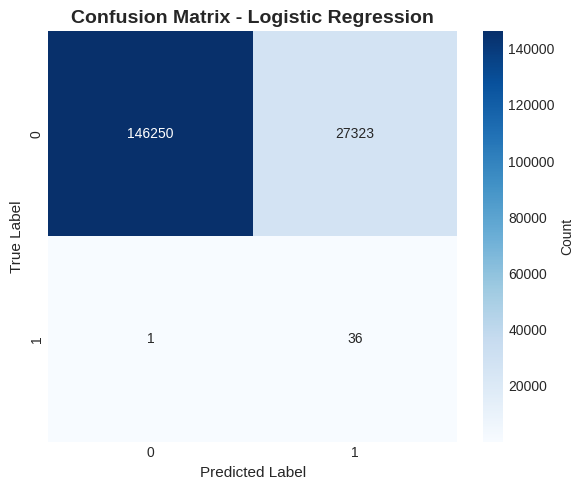


🎯 MODEL: Random Forest
📈 F1-Score (macro):   0.7845
📈 Recall class 1:     1.0000
📈 Accuracy:           0.9997

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    173573
           1       0.40      1.00      0.57        37

    accuracy                           1.00    173610
   macro avg       0.70      1.00      0.78    173610
weighted avg       1.00      1.00      1.00    173610

⏱️ Training time for Random Forest: 151.35 seconds



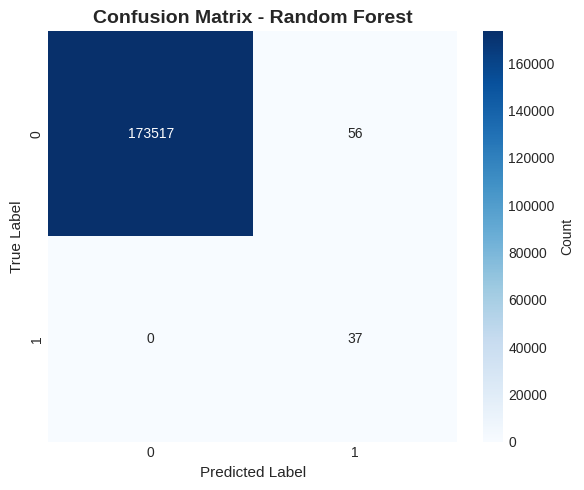


🎯 MODEL: XGBoost
📈 F1-Score (macro):   0.7845
📈 Recall class 1:     1.0000
📈 Accuracy:           0.9997

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    173573
           1       0.40      1.00      0.57        37

    accuracy                           1.00    173610
   macro avg       0.70      1.00      0.78    173610
weighted avg       1.00      1.00      1.00    173610

⏱️ Training time for XGBoost: 41.15 seconds



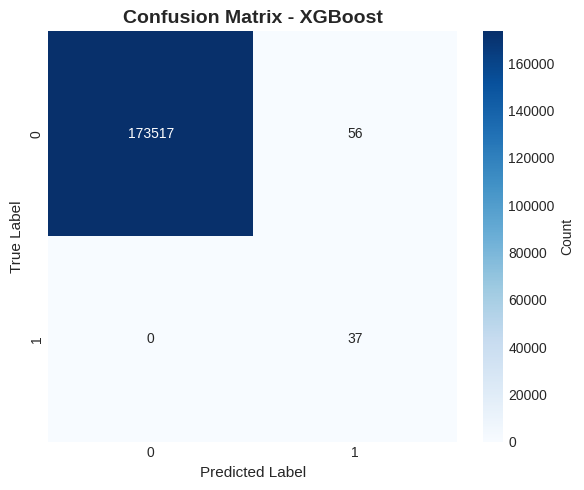


🎯 MODEL: LightGBM
📈 F1-Score (macro):   0.7845
📈 Recall class 1:     1.0000
📈 Accuracy:           0.9997

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    173573
           1       0.40      1.00      0.57        37

    accuracy                           1.00    173610
   macro avg       0.70      1.00      0.78    173610
weighted avg       1.00      1.00      1.00    173610

⏱️ Training time for LightGBM: 29.26 seconds



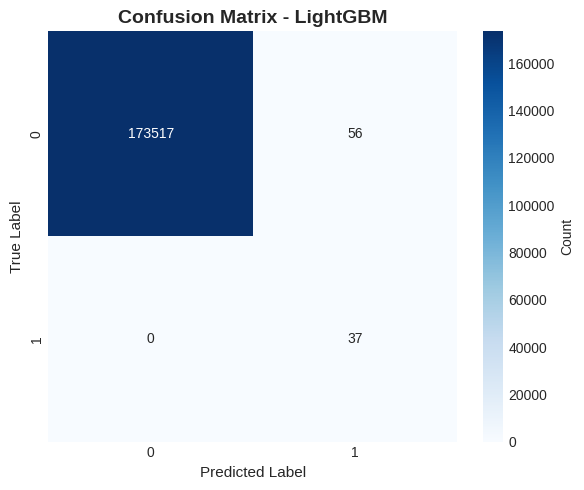


📊 BASELINE RESULTS SUMMARY
              Model  F1-Score  Accuracy  Train Time (s)
      Random Forest  0.784535  0.999677      151.353641
            XGBoost  0.784535  0.999677       41.150570
           LightGBM  0.784535  0.999677       29.256812
Logistic Regression  0.458597  0.842613       28.907402
✅ Saved: ../models/baseline/logistic_regression_baseline.pkl
✅ Saved: ../models/baseline/random_forest_baseline.pkl
✅ Saved: ../models/baseline/xgboost_baseline.json
✅ Saved: ../models/baseline/lightgbm_baseline.pkl

💾 All baseline models saved to: ../models/baseline/


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb


BASELINE_SAVE_PATH = '../models/baseline'
IMAGE_SAVE_PATH = '../images'


def plot_confusion_matrix(y_true, y_pred, model_name, figsize=(6, 5)):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label', fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{IMAGE_SAVE_PATH}/cfs_mtx_{model_name}.png")
    plt.show()


def print_model_results(model_name, y_true, y_pred, show_report=True):
    f1_macro = f1_score(y_true, y_pred, average='macro')
    recall_dict = classification_report(y_true, y_pred, output_dict=True, digits=4)
    recall_class_1 = recall_dict.get('1', {}).get('recall', 0.0)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{'='*70}")
    print(f"🎯 MODEL: {model_name}")
    print(f"{'='*70}")
    print(f"📈 F1-Score (macro):   {f1_macro:.4f}")
    print(f"📈 Recall class 1:     {recall_class_1:.4f}")
    print(f"📈 Accuracy:           {acc:.4f}")

    if show_report:
        print(f"\n📋 Classification Report:")
        print(classification_report(y_true, y_pred))

    return f1_macro, recall_class_1, acc


print("="*70)
print("🔬 BASELINE MODELS TRAINING")
print("="*70)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
baseline_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=500,
        solver='lbfgs',
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        random_state=42,
        class_weight='balanced'
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist"
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary',
        class_weight={0:1, 1:scale_pos_weight},
        random_state=42,
        verbose=-1
    )
}

baseline_results = {}

print(f"\n🎯 Training {len(baseline_models)} baseline models...\n")

for name in tqdm(baseline_models.keys(), desc="Training Models"):
    model = baseline_models[name]

    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    elapsed_time = time.time() - start_time

    y_pred = model.predict(X_test_scaled)

    f1_macro, recall_class_1, acc = print_model_results(name, y_test, y_pred, show_report=True)

    baseline_results[name] = {
        'model': model,
        'f1_score': f1_macro,
        'recall_class_1': recall_class_1,
        'accuracy': acc,
        'predictions': y_pred,
        'train_time_sec': elapsed_time
    }

    print(f"⏱️ Training time for {name}: {elapsed_time:.2f} seconds\n")
    plot_confusion_matrix(y_test, y_pred, name)

print(f"\n{'='*70}")
print("📊 BASELINE RESULTS SUMMARY")
print(f"{'='*70}")

summary_df = pd.DataFrame({
    'Model': list(baseline_results.keys()),
    'F1-Score': [r['f1_score'] for r in baseline_results.values()],
    'Accuracy': [r['accuracy'] for r in baseline_results.values()],
    'Train Time (s)': [r['train_time_sec'] for r in baseline_results.values()]
})
summary_df = summary_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))

os.makedirs(BASELINE_SAVE_PATH, exist_ok=True)
for name, result in baseline_results.items():
    filename = f"{name.lower().replace(' ', '_')}_baseline.pkl"
    filepath = os.path.join(BASELINE_SAVE_PATH, filename)

    if isinstance(result['model'], xgb.XGBModel):
        booster_path = filepath.replace('.pkl', '.json')
        result['model'].get_booster().save_model(booster_path)
        print(f"✅ Saved: {booster_path}")
    else:
        joblib.dump(result['model'], filepath)
        print(f"✅ Saved: {filepath}")

print(f"\n💾 All baseline models saved to: {BASELINE_SAVE_PATH}/")

## Finetuning Model

🎛️  HYPERPARAMETER TUNING

🎛️  Tuning Logistic Regression...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
✅ Best CV Average Precision: 0.8114
🎯 Test Average Precision: 0.1862
⏱️ Train + Tune Time: 656.59 sec

🎛️  Tuning Random Forest...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

✅ Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 30}
✅ Best CV Average Precision: 0.8215
⏱️ Train + Tune Time: 717.08 sec
🎯 Test Average Precision: 0.6434

🎛️  Tuning XGBoost...


Optuna XGBoost Trials:   0%|          | 0/50 [00:00<?, ?it/s]


✅ Best Parameters: {'max_depth': 5, 'learning_rate': 0.04423613330854118, 'min_child_weight': 0.09497383052050448, 'gamma': 2.731029974282232, 'subsample': 0.6113336601735676, 'colsample_bytree': 0.969351299642678, 'reg_alpha': 2.4732413696735316, 'reg_lambda': 4.435455098526105}
✅ Best Average Precision: 0.7756
⏱️ Train + Tune Time: 1605.18 sec

🎛️  Tuning LightGBM...


Optuna LightGBM Trials:   0%|          | 0/50 [00:00<?, ?it/s]


✅ Best Parameters: {'num_leaves': 42, 'learning_rate': 0.1422607995159737, 'min_child_samples': 57, 'min_child_weight': 0.07328050768425814, 'subsample': 0.5500721762685552, 'colsample_bytree': 0.7078536900882476, 'reg_alpha': 4.301918178803561, 'reg_lambda': 3.110901564878279, 'max_depth': 18, 'subsample_freq': 4}
✅ Best Average Precision: 0.8130
⏱️ Train + Tune Time: 1898.18 sec

🏆 ĐÁNH GIÁ SAU FINE-TUNING

🎯 MODEL: Logistic Regression
📈 F1-Score (macro):   0.4955
📈 Recall class 1:     0.9730
📈 Accuracy:           0.9615

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    173573
           1       0.01      0.97      0.01        37

    accuracy                           0.96    173610
   macro avg       0.50      0.97      0.50    173610
weighted avg       1.00      0.96      0.98    173610



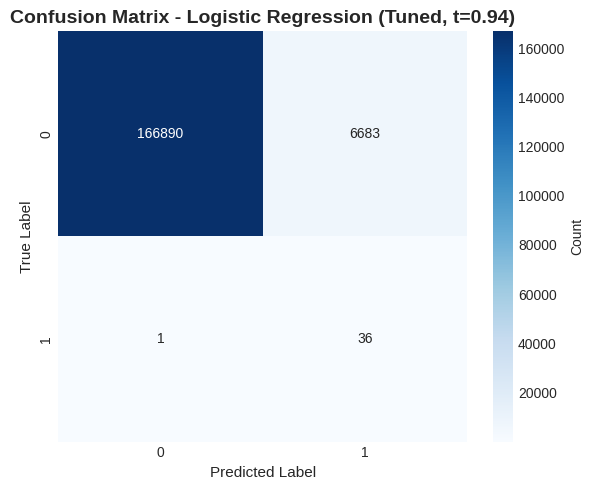


🎯 MODEL: Random Forest
📈 F1-Score (macro):   0.7920
📈 Recall class 1:     0.8919
📈 Accuracy:           0.9997

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    173573
           1       0.43      0.89      0.58        37

    accuracy                           1.00    173610
   macro avg       0.72      0.95      0.79    173610
weighted avg       1.00      1.00      1.00    173610



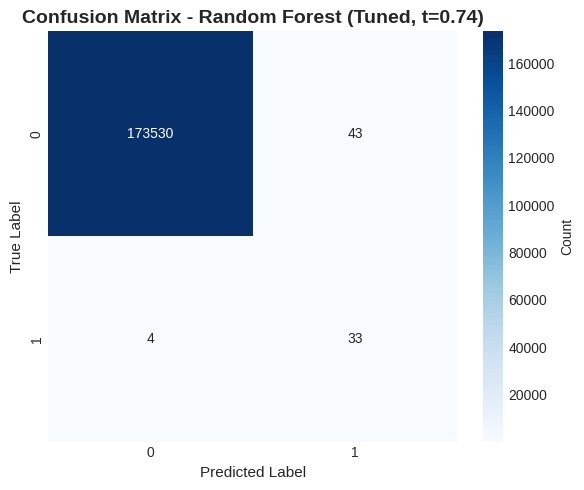


🎯 MODEL: XGBoost
📈 F1-Score (macro):   0.7802
📈 Recall class 1:     1.0000
📈 Accuracy:           0.9997

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    173573
           1       0.39      1.00      0.56        37

    accuracy                           1.00    173610
   macro avg       0.69      1.00      0.78    173610
weighted avg       1.00      1.00      1.00    173610



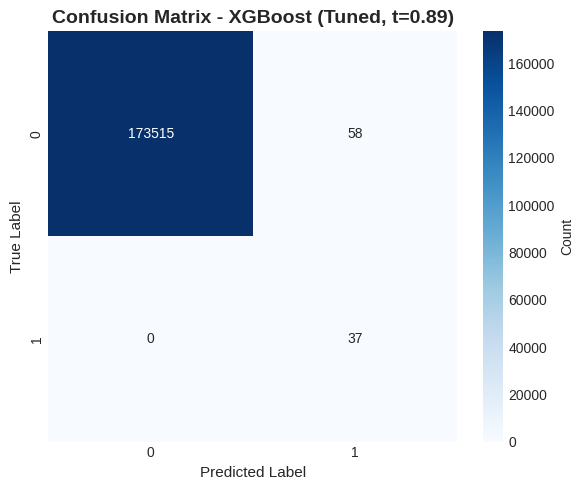


🎯 MODEL: LightGBM
📈 F1-Score (macro):   0.8437
📈 Recall class 1:     0.8919
📈 Accuracy:           0.9998

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    173573
           1       0.56      0.89      0.69        37

    accuracy                           1.00    173610
   macro avg       0.78      0.95      0.84    173610
weighted avg       1.00      1.00      1.00    173610



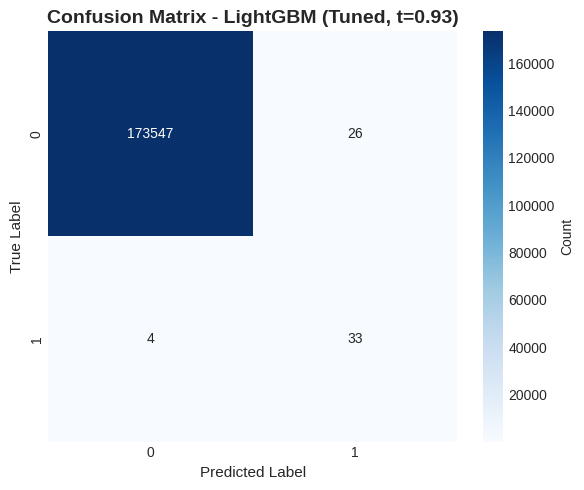


📊 TUNED MODELS SUMMARY
              Model  F1-Score  Accuracy  Train/Tune Time (s)
           LightGBM  0.843707  0.999827          1898.178208
      Random Forest  0.791968  0.999729           717.081930
            XGBoost  0.780219  0.999666          1605.177378
Logistic Regression  0.495513  0.961500           656.585314
✅ Saved: ../models/tuned/logistic_regression_tuned.pkl
✅ Saved: ../models/tuned/random_forest_tuned.pkl
✅ Saved: ../models/tuned/xgboost_tuned.json
✅ Saved: ../models/tuned/lightgbm_tuned.pkl

✅ HOÀN THÀNH!

📂 Tuned models saved to: ../models/tuned/
✅ Saved metadata (PKL): ../models/metadata_20251223_194345.pkl
✅ Saved metadata (JSON): ../models/metadata_20251223_194345.json


In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import optuna
from optuna.samplers import TPESampler
import json

optuna.logging.set_verbosity(optuna.logging.WARNING)


TUNED_SAVE_PATH = '../models/tuned'
METADATA_SAVE_PATH = '../models'


def tune_logistic_regression(X_train_scaled, y_train, X_test_scaled, y_test):
    print(f"\n{'='*70}")
    print("🎛️  Tuning Logistic Regression...")
    print(f"{'='*70}")

    model = LogisticRegression(max_iter=500, solver='lbfgs', class_weight='balanced', random_state=42)

    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear']
    }

    grid = GridSearchCV(
        model,
        param_grid,
        scoring='average_precision',
        cv=3,
        n_jobs=-1,
        verbose=2
    )

    start_time = time.time()
    grid.fit(X_train_scaled, y_train)
    elapsed_time = time.time() - start_time

    best_model = grid.best_estimator_

    print(f"\n✅ Best Parameters: {grid.best_params_}")
    print(f"✅ Best CV Average Precision: {grid.best_score_:.4f}")

    y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
    ap_test = average_precision_score(y_test, y_proba_test)
    print(f"🎯 Test Average Precision: {ap_test:.4f}")
    print(f"⏱️ Train + Tune Time: {elapsed_time:.2f} sec")

    return best_model, elapsed_time


def tune_random_forest(X_train_scaled, y_train, X_test_scaled, y_test, n_iter=5):
    print(f"\n{'='*70}")
    print("🎛️  Tuning Random Forest...")
    print(f"{'='*70}")

    model = RandomForestClassifier(class_weight='balanced', random_state=42)

    param_dist = {
        'n_estimators': [200, 500, 800],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }

    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='average_precision',
        cv=3,
        n_jobs=-1,
        verbose=2,
        random_state=42
    )

    start_time = time.time()
    random_search.fit(X_train_scaled, y_train)
    elapsed_time = time.time() - start_time

    print(f"\n✅ Best Parameters: {random_search.best_params_}")
    print(f"✅ Best CV Average Precision: {random_search.best_score_:.4f}")
    print(f"⏱️ Train + Tune Time: {elapsed_time:.2f} sec")

    best_model = random_search.best_estimator_

    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    ap_test = average_precision_score(y_test, y_proba)
    print(f"🎯 Test Average Precision: {ap_test:.4f}")

    return best_model, elapsed_time


def tune_xgboost(X_train_scaled, y_train, X_test_scaled, y_test):
    print(f"\n{'='*70}")
    print("🎛️  Tuning XGBoost...")
    print(f"{'='*70}")

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    def objective_xgb(trial):
        param = {
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'booster': 'gbtree',
            'tree_method': 'hist',
            'n_estimators': 500,
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 10.0, log=True),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'verbosity': 0
        }

        model = xgb.XGBClassifier(**param)
        model.fit(X_train_scaled, y_train)

        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        return average_precision_score(y_test, y_proba)

    study_xgb = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=42)
    )

    start_time = time.time()

    with tqdm(total=50, desc="Optuna XGBoost Trials") as pbar:
        def callback(study, trial):
            pbar.update(1)
            pbar.set_postfix({'Best AP': f"{study.best_value:.4f}"})
        study_xgb.optimize(objective_xgb, n_trials=50, callbacks=[callback])

    elapsed_time = time.time() - start_time

    print(f"\n✅ Best Parameters: {study_xgb.best_params}")
    print(f"✅ Best Average Precision: {study_xgb.best_value:.4f}")
    print(f"⏱️ Train + Tune Time: {elapsed_time:.2f} sec")

    xgb_model = xgb.XGBClassifier(
        n_estimators=500,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss',
        **study_xgb.best_params
    )
    xgb_model.fit(X_train_scaled, y_train)

    return xgb_model, elapsed_time


def tune_lightgbm(X_train_scaled, y_train, X_test_scaled, y_test):
    print(f"\n{'='*70}")
    print("🎛️  Tuning LightGBM...")
    print(f"{'='*70}")

    def objective_lgb(trial):
        param = {
            'n_estimators': 500,
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 10.0, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'subsample_freq': trial.suggest_int('subsample_freq', 1, 10),
            'class_weight': 'balanced',
            'random_state': 42,
            'verbose': -1
        }

        model = lgb.LGBMClassifier(**param)
        model.fit(X_train_scaled, y_train)

        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        return average_precision_score(y_test, y_proba)

    study_lgb = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=42)
    )

    start_time = time.time()

    with tqdm(total=50, desc="Optuna LightGBM Trials") as pbar:
        def callback(study, trial):
            pbar.update(1)
            pbar.set_postfix({'Best AP': f"{study.best_value:.4f}"})
        study_lgb.optimize(objective_lgb, n_trials=50, callbacks=[callback])

    elapsed_time = time.time() - start_time

    print(f"\n✅ Best Parameters: {study_lgb.best_params}")
    print(f"✅ Best Average Precision: {study_lgb.best_value:.4f}")
    print(f"⏱️ Train + Tune Time: {elapsed_time:.2f} sec")

    lgb_model = lgb.LGBMClassifier(
        n_estimators=500,
        class_weight='balanced',
        random_state=42,
        verbose=-1,
        **study_lgb.best_params
    )
    lgb_model.fit(X_train_scaled, y_train)

    return lgb_model, elapsed_time

def find_best_threshold(y_true, y_proba, metric='f1'):
    thresholds = np.linspace(0.05, 0.95, 100)

    best_t = 0.5
    best_score = -1

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        if metric == 'f1':
            score = f1_score(y_true, y_pred)
        else:
            raise ValueError("Only f1 supported for now")

        if score > best_score:
            best_score = score
            best_t = t

    return best_t, best_score


print("="*70)
print("🎛️  HYPERPARAMETER TUNING")
print("="*70)

lr_model, lr_time = tune_logistic_regression(X_train_scaled, y_train, X_test_scaled, y_test)
rf_model, rf_time = tune_random_forest(X_train_scaled, y_train, X_test_scaled, y_test)
xgb_model, xgb_time = tune_xgboost(X_train_scaled, y_train, X_test_scaled, y_test)
lgb_model, lgb_time = tune_lightgbm(X_train_scaled, y_train, X_test_scaled, y_test)

tuned_models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model
}

tuned_times = {
    'Logistic Regression': lr_time,
    'Random Forest': rf_time,
    'XGBoost': xgb_time,
    'LightGBM': lgb_time
}

print("\n" + "="*70)
print("🏆 ĐÁNH GIÁ SAU FINE-TUNING")
print("="*70)

tuned_results = {}

for name, model in tuned_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    best_t, best_f1 = find_best_threshold(y_test, y_proba)
    y_pred = (y_proba >= best_t).astype(int)
    f1_macro, recall_class_1, acc = print_model_results(
        name, y_test, y_pred, show_report=True
    )

    tuned_results[name] = {
        'model': model,
        'f1_score': f1_macro,
        'recall_class_1': recall_class_1,
        'accuracy': acc,
        'best_threshold': best_t,
        'f1_at_best_threshold': best_f1,
        'train_time_sec': tuned_times.get(name, None)
    }

    plot_confusion_matrix(y_test, y_pred, f"{name} (Tuned, t={best_t:.2f})")


print(f"\n{'='*70}")
print("📊 TUNED MODELS SUMMARY")
print(f"{'='*70}")
summary_df = pd.DataFrame({
    'Model': list(tuned_results.keys()),
    'F1-Score': [r['f1_score'] for r in tuned_results.values()],
    'Accuracy': [r['accuracy'] for r in tuned_results.values()],
    'Train/Tune Time (s)': [r['train_time_sec'] for r in tuned_results.values()]
})
summary_df = summary_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))

os.makedirs(TUNED_SAVE_PATH, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

for name, result in tuned_results.items():
    filename = f"{name.lower().replace(' ', '_')}_tuned.pkl"
    filepath = os.path.join(TUNED_SAVE_PATH, filename)

    if isinstance(result['model'], xgb.XGBModel):
        booster_path = filepath.replace('.pkl', '.json')
        result['model'].get_booster().save_model(booster_path)
        print(f"✅ Saved: {booster_path}")
    else:
        joblib.dump(result['model'], filepath)
        print(f"✅ Saved: {filepath}")

metadata = {
    'timestamp': timestamp,
    'optimized_metric': 'f1',
    'models': {}
}

for name, res in tuned_results.items():
    metadata['models'][name] = {
        'f1_score': res['f1_score'],
        'accuracy': res['accuracy'],
        'recall_class_1': res['recall_class_1'],
        'best_threshold': res['best_threshold'],
        'f1_at_best_threshold': res['f1_at_best_threshold'],
        'train_time_sec': res['train_time_sec']
    }

os.makedirs(METADATA_SAVE_PATH, exist_ok=True)

metadata_pkl_path = f"{METADATA_SAVE_PATH}/metadata_{timestamp}.pkl"
metadata_json_path = f"{METADATA_SAVE_PATH}/metadata_{timestamp}.json"

joblib.dump(metadata, metadata_pkl_path)

with open(metadata_json_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print(f"\n{'='*70}")
print("✅ HOÀN THÀNH!")
print(f"{'='*70}")
print(f"\n📂 Tuned models saved to: {TUNED_SAVE_PATH}/")

print(f"✅ Saved metadata (PKL): {metadata_pkl_path}")
print(f"✅ Saved metadata (JSON): {metadata_json_path}")
